In [ ]:
!pip -q install decord matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 129.9 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/Sid430/cataract-videomae-pretrain.git


Cloning into 'cataract-videomae-pretrain'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 52 (delta 16), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 30.50 MiB | 11.74 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [ ]:
%cd /content/cataract-videomae-pretrain

/content/cataract-videomae-pretrain


In [ ]:
!wget -O /content/data.tar "https://www.dropbox.com/scl/fi/igderi5zi2l80ujxsajt8/CataractVidoes4ssl.tar?rlkey=j6n9bs6sp2vfcy07cl1n1z78i&dl=1"


--2026-07-08 12:59:57--  https://www.dropbox.com/scl/fi/igderi5zi2l80ujxsajt8/CataractVidoes4ssl.tar?rlkey=j6n9bs6sp2vfcy07cl1n1z78i&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.85.18, 2620:100:6030:18::a27d:5012
Connecting to www.dropbox.com (www.dropbox.com)|162.125.85.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc49f48e6fe5bba00cb95e15ca42.dl.dropboxusercontent.com/cd/0/inline/DD3NLgseYUTOaYplzECADMGrOQOnoPJG2y7H-mIq19qvJsDu0zxzDW3cbj0TECtYB_UTz0d0MbpPI3X195uvhTVKEH2Q09lkVNoLmxzPOJ7NgOfebwZwFSpA_pjYAEvjxUyvaQmMEUcWlyXpeZO-627j/file?dl=1# [following]
--2026-07-08 12:59:58--  https://uc49f48e6fe5bba00cb95e15ca42.dl.dropboxusercontent.com/cd/0/inline/DD3NLgseYUTOaYplzECADMGrOQOnoPJG2y7H-mIq19qvJsDu0zxzDW3cbj0TECtYB_UTz0d0MbpPI3X195uvhTVKEH2Q09lkVNoLmxzPOJ7NgOfebwZwFSpA_pjYAEvjxUyvaQmMEUcWlyXpeZO-627j/file?dl=1
Resolving uc49f48e6fe5bba00cb95e15ca42.dl.dropboxusercontent.com (uc49f48e6fe5bba00cb95e15ca42.dl.dropboxusercontent.

In [ ]:
!mkdir -p /content/cataract-videomae-pretrain/data


In [ ]:
!tar -xf /content/data.tar -C /content/cataract-videomae-pretrain/data


In [ ]:
!echo "files:" && ls /content/cataract-videomae-pretrain/data/moha_Raw_Videos_4SSL/*.mp4 | wc -l


files:
2742


In [ ]:
import torch
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
DATA_ROOT = "/content/cataract-videomae-pretrain/data/moha_Raw_Videos_4SSL"
VJEPA_OUT = "checkpoints_vjepa"
MODEL, BATCH_SIZE, EPOCHS, IMG_SIZE, NUM_FRAMES = "base", 16, 800, 224, 16

import os
print("data root:", os.path.abspath(DATA_ROOT))
print("output dir:", os.path.abspath(VJEPA_OUT))

data root: /content/cataract-videomae-pretrain/data/moha_Raw_Videos_4SSL
output dir: /content/cataract-videomae-pretrain/checkpoints_vjepa


In [ ]:
import os
print("cwd:", os.getcwd())
print("contents:", os.listdir("."))

cwd: /content/cataract-videomae-pretrain
contents: ['README.md', 'pretainvjepa.py', 'models', 'pretrain.ipynb', '.git', 'checkpoints', 'plot_utils.py', 'datasets.py', 'check_data.py', 'pretrain.py', 'data', 'configs']


In [ ]:
import sys; sys.path.append(".")
from data.datasets import CataractVideoDataset

ds = CataractVideoDataset(DATA_ROOT, mode="video",
                          num_frames=NUM_FRAMES, img_size=IMG_SIZE, sampling_stride=4)
print("backend:", ds.backend, "| clips found:", len(ds))
clip = ds[0]
print("sample clip shape:", tuple(clip.shape), "dtype:", clip.dtype,
      "min %.2f max %.2f" % (clip.min(), clip.max()))
assert tuple(clip.shape) == (3, NUM_FRAMES, IMG_SIZE, IMG_SIZE), "unexpected clip shape"
print("OK - ready to train")

backend: decord | clips found: 2742
sample clip shape: (3, 16, 224, 224) dtype: torch.float32 min -2.12 max 2.64
OK - ready to train


In [ ]:
cmd = f'''python pretrain_vjepa.py \
  --data-root "{DATA_ROOT}" --data-mode video \
  --model {MODEL} --batch-size 4 --accum-steps 16 --amp --grad-checkpoint --epochs {EPOCHS} \
  --img-size {IMG_SIZE} --num-frames {NUM_FRAMES} \
  --amp --num-workers 8 \
  --early-stop-patience 15 --early-stop-min-delta 1e-4 \
  --out-dir "{VJEPA_OUT}"'''
print(cmd)
get_ipython().system(cmd)

python pretrain_vjepa.py   --data-root "/content/cataract-videomae-pretrain/data/moha_Raw_Videos_4SSL" --data-mode video   --model base --batch-size 4 --accum-steps 16 --amp --grad-checkpoint --epochs 800   --img-size 224 --num-frames 16   --amp --num-workers 8   --early-stop-patience 15 --early-stop-min-delta 1e-4   --out-dir "checkpoints_vjepa"
[model] V-JEPA2-base | 108.1M trainable | 1568 tokens | device=cuda
[mem] gradient checkpointing enabled on encoder + predictor
[optim] batch=4 accum=16 effective_batch=64
  epoch 0 step 160/685 loss 0.8489 lr 1.46e-07 ema 0.9960
  epoch 0 step 320/685 loss 0.8473 lr 2.92e-07 ema 0.9960
  epoch 0 step 480/685 loss 0.8299 lr 4.38e-07 ema 0.9960
  epoch 0 step 640/685 loss 0.8167 lr 5.84e-07 ema 0.9960
[epoch 0] avg_loss 0.8403 time 297.6s
  epoch 1 step 112/685 loss 0.8027 lr 7.30e-07 ema 0.9960
  epoch 1 step 272/685 loss 0.7917 lr 8.76e-07 ema 0.9960
  epoch 1 step 432/685 loss 0.7776 lr 1.02e-06 ema 0.9960
  epoch 1 step 592/685 loss 0.7473 

logged 52745 steps across 77 epochs


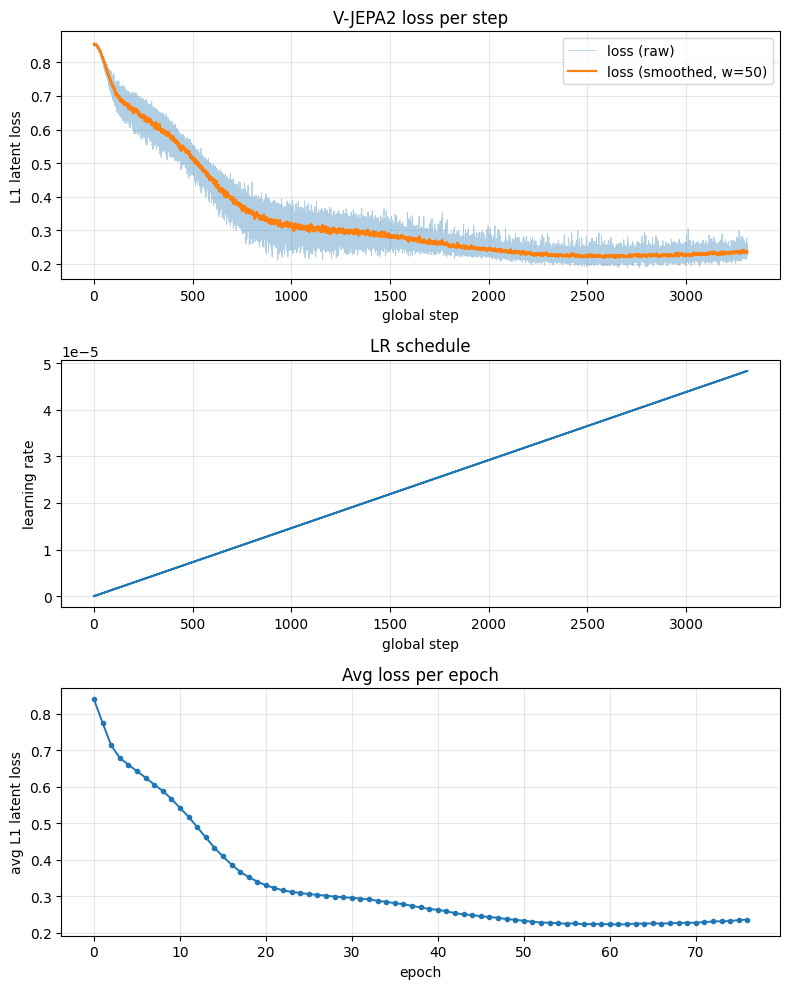

[plot] wrote checkpoints_vjepa/learning_curve.pdf


'checkpoints_vjepa/learning_curve.pdf'

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from plot_utils import load_step_metrics, load_epoch_metrics, _smooth, make_curves_pdf
steps  = load_step_metrics(VJEPA_OUT)
epochs = load_epoch_metrics(VJEPA_OUT)
print(f"logged {len(steps)} steps across {len(epochs)} epochs")
SMOOTH = 50
fig, axes = plt.subplots(3, 1, figsize=(8, 10))
if steps:
    gs=[r["gstep"] for r in steps]; ls=[r["loss"] for r in steps]
    axes[0].plot(gs, ls, lw=0.6, alpha=0.35, label="loss (raw)")
    axes[0].plot(gs, _smooth(ls, SMOOTH), lw=1.6, label=f"loss (smoothed, w={SMOOTH})")
    axes[0].set(xlabel="global step", ylabel="L1 latent loss", title="V-JEPA2 loss per step"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(gs, [r["lr"] for r in steps], lw=1.4)
    axes[1].set(xlabel="global step", ylabel="learning rate", title="LR schedule"); axes[1].grid(alpha=0.3)
if epochs:
    axes[2].plot([e["epoch"] for e in epochs], [e["avg_loss"] for e in epochs], marker="o", ms=3, lw=1.4)
    axes[2].set(xlabel="epoch", ylabel="avg L1 latent loss", title="Avg loss per epoch"); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
make_curves_pdf(VJEPA_OUT)

In [ ]:
import shutil
shutil.make_archive("/content/checkpoints_vjepa", "zip", "checkpoints_vjepa")

from google.colab import files
files.download("/content/checkpoints_vjepa.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>